In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, f1_score,confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier

In [2]:
RANDOM_STATE = 42

# Cargar datos


In [3]:
# Cargamos el dataset
df = pd.read_csv('dataset/cs-training.csv')

# Limpiar dataset


In [4]:
delinquency_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]


# El dataset tiene valores 96 y 98 en las columnas de morosidad, que representan "No reportado" y "Desconocido", respectivamente. Reemplazamos estos valores con NaN y luego los rellenamos con la moda de cada columna.
for col in delinquency_cols:
    df[col] = df[col].replace([96, 98], np.nan)
    df[col] = df[col].fillna(df[col].mode()[0])
    

In [5]:
# Edad = 0 no tiene sentido, remplazar por la mediana
df.loc[df["age"] == 0, "age"] = df["age"].median()    

# Feature Engineering


In [6]:
# Donde se encuentra el valor nulo de MonthlyIncome, se crea una nueva columna que indica si el valor estaba ausente o no. Esto puede ser útil para modelos de machine learning que pueden beneficiarse de esta información adicional.
df['MonthlyIncome_was_missing'] = df['MonthlyIncome'].isnull().astype(int)


# Se agrupan los datos por rangos de edad y se calcula la mediana de MonthlyIncome para cada grupo. Luego, se utiliza esta mediana para rellenar los valores nulos de MonthlyIncome dentro de cada grupo de edad. Esto permite una imputación más precisa basada en la edad del individuo.
df["age_bucket"] = pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 65, 120])
df["MonthlyIncome"] = df.groupby("age_bucket", observed=True)["MonthlyIncome"].transform(lambda x: x.fillna(x.median()))
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

# No se utiliza la columna "age_bucket" después de la imputación, por lo que se elimina del DataFrame para mantenerlo limpio y evitar confusiones en análisis posteriores.
df = df.drop(columns=["age_bucket"])



In [7]:
# Si no se reporta numero de dependientes, asumimos que no tiene dependientes y rellenamos con 0
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)

In [8]:
# Aplicamos un winsorizing a las columnas debido al imbalance de los datos y la presencia de outliers.

for col in ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio"]:
    trainingCap = df[col].quantile(0.99)
    
    df[col] = np.where(df[col] > trainingCap, trainingCap, df[col])
    


print("Missing values after cleaning:")
print(df.isnull().sum(), "Should be 0")


Missing values after cleaning:
Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_was_missing               0
dtype: int64 Should be 0


In [9]:
# Hacemos un historial de pagos atrasados sumando las tres columnas que representan los diferentes rangos de días de atraso.
df["TotalPastDue"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"]
    + df["NumberOfTime60-89DaysPastDueNotWorse"]
    + df["NumberOfTimes90DaysLate"]
)

# Creamos una nueva característica que representa el ingreso mensual por dependiente, individualmente por persona
df["IncomePerDependent"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)

 # Creamos una nueva característica que representa la cantidad de líneas de crédito abiertas por año de edad
df["CreditLinesPerAge"] = df["NumberOfOpenCreditLinesAndLoans"] / df["age"]

In [10]:
# Bandera binaria que indica si la utilización de lineas de crédito no aseguradas es mayor al 80%
df["HighUtilizationFlag"] = (df["RevolvingUtilizationOfUnsecuredLines"] > 0.8).astype(int)

# Variable objetivo y características
target = "SeriousDlqin2yrs"
features = [c for c in df.columns if c != target]
 
X = df[features]
y = df[target]
 
print(f"\nFeatures finales ({len(features)}): {features}")


Features finales (16): ['Unnamed: 0', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_was_missing', 'TotalPastDue', 'IncomePerDependent', 'CreditLinesPerAge', 'HighUtilizationFlag']


# Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Tasa de positivos train: {y_train.mean():.4f} / test: {y_test.mean():.4f}")


Train: (112500, 16), Test: (37500, 16)
Tasa de positivos train: 0.0668 / test: 0.0668


# Random Forest

In [12]:
# Probamos un modelo de Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",  
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)
 
print("\n=== RANDOM FOREST (baseline) ===")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")
print(f"F1: {f1_score(y_test, rf_pred):.4f}")


=== RANDOM FOREST (baseline) ===
ROC-AUC: 0.8649
F1: 0.3537


# XGBOOST


In [13]:
# probamos un modelo XGBOOST

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
 
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred = xgb.predict(X_test)
 
print("\n=== XGBOOST ===")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"F1: {f1_score(y_test, xgb_pred):.4f}")



=== XGBOOST ===
ROC-AUC: 0.8658
F1: 0.3489


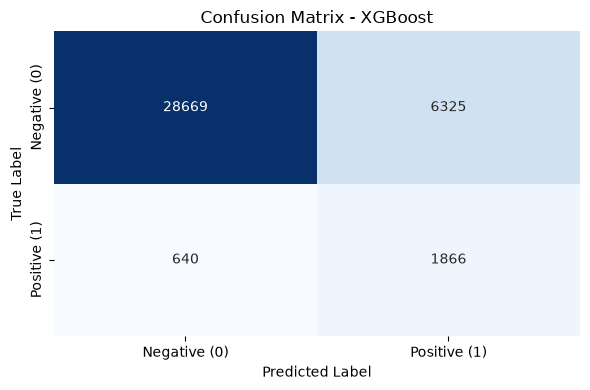

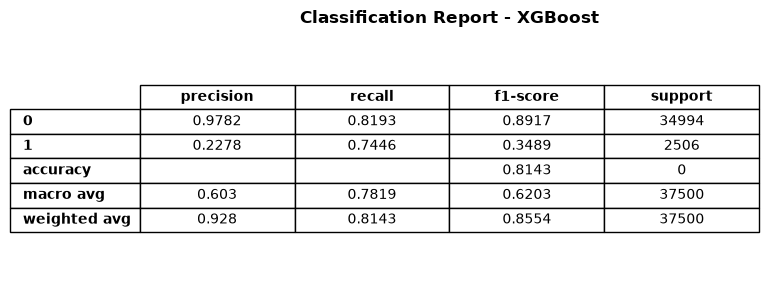

In [14]:
# Matriz de confusión

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Negative (0)", "Positive (1)"],
            yticklabels=["Negative (0)", "Positive (1)"])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# 2. Reporte de clasificación
report_dict = classification_report(y_test, xgb_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T.round(4)

report_df["support"] = report_df["support"].astype(int)
report_df = report_df.astype(str)


report_df.loc["accuracy", ["precision", "recall"]] = ""

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")

table = ax.table(
    cellText=report_df.values,
    rowLabels=report_df.index,
    colLabels=report_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.4)

for key, cell in table.get_celld().items():
    if key[0] == 0 or key[1] == -1:
        cell.get_text().set_weight("bold")

plt.title("Classification Report - XGBoost", pad=10, fontweight="bold")
plt.tight_layout()
plt.show()

# Feature Importance

In [15]:
# Evaluamos la importancia de las características utilizando el modelo XGBoost. Esto nos permite identificar qué variables tienen un mayor impacto en la predicción del modelo, lo cual es útil para la interpretación y mejora del modelo.
importances = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
print("\n=== Feature importance (XGBoost) ===")
print(importances)


=== Feature importance (XGBoost) ===
TotalPastDue                            0.448434
HighUtilizationFlag                     0.108630
RevolvingUtilizationOfUnsecuredLines    0.085209
NumberOfTimes90DaysLate                 0.068065
NumberOfTime30-59DaysPastDueNotWorse    0.048683
NumberOfTime60-89DaysPastDueNotWorse    0.047266
NumberRealEstateLoansOrLines            0.028538
MonthlyIncome_was_missing               0.024752
CreditLinesPerAge                       0.024160
age                                     0.020648
DebtRatio                               0.018513
NumberOfOpenCreditLinesAndLoans         0.016706
MonthlyIncome                           0.016695
IncomePerDependent                      0.015509
Unnamed: 0                              0.014336
NumberOfDependents                      0.013856
dtype: float32


# Guardar modelo

In [16]:
import joblib

In [17]:
'''
joblib.dump(xgb, "C:\\Users\\gerad\\Documents\\ProyectoHackathon\\Model\\xgb_model.joblib")
importances.to_csv("C:\\Users\\gerad\\Documents\\ProyectoHackathon\\Model\\feature_importance.csv")
 
print("\nModelo guardado en /mnt/user-data/outputs/xgb_model.joblib")'''

'\njoblib.dump(xgb, "C:\\Users\\gerad\\Documents\\ProyectoHackathon\\Model\\xgb_model.joblib")\nimportances.to_csv("C:\\Users\\gerad\\Documents\\ProyectoHackathon\\Model\\feature_importance.csv")\n\nprint("\nModelo guardado en /mnt/user-data/outputs/xgb_model.joblib")'

=== Tamaño de muestra por bin de edad ===
age_bucket
(0, 25]       3027
(25, 35]     18458
(35, 45]     29819
(45, 55]     36691
(55, 65]     33406
(65, 120]    28599
Name: count, dtype: int64

=== Media por bin de edad ===
            DebtRatio  RevolvingUtilizationOfUnsecuredLines  MonthlyIncome  \
age_bucket                                                                   
(0, 25]        42.920                                 0.548       1914.366   
(25, 35]      158.694                                 0.461       4463.465   
(35, 45]      297.876                                 0.388       6594.416   
(45, 55]      364.199                                 0.338       7405.183   
(55, 65]      425.917                                 0.268       7252.254   
(65, 120]     277.977                                 0.174       5827.241   

            NumberOfTime30-59DaysPastDueNotWorse  \
age_bucket                                         
(0, 25]                                    0.14

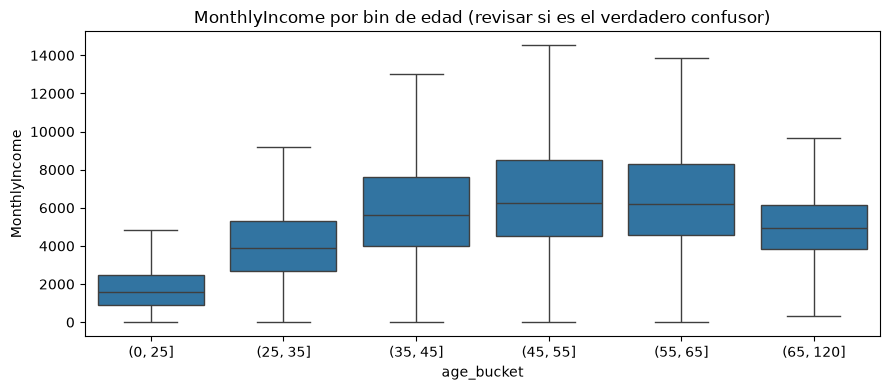

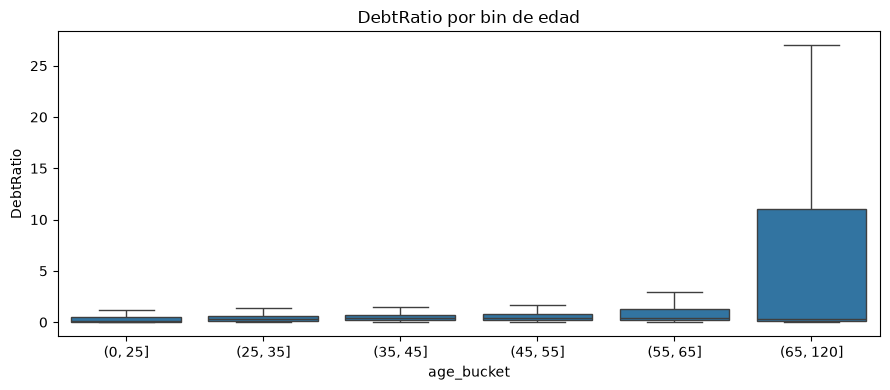

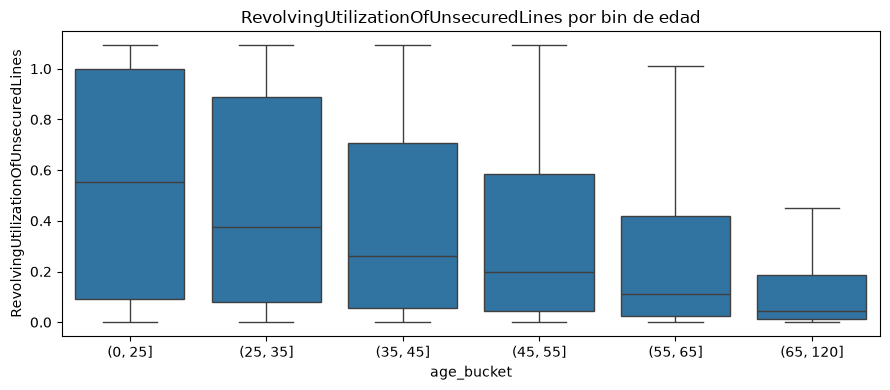

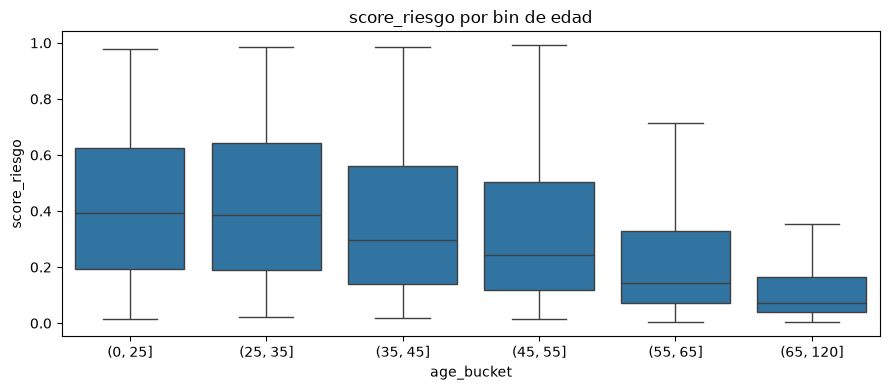

In [ ]:
analisis = df.copy()

# Mismos bins de edad que ya usaste en el preprocesamiento (celda 7)
analisis["age_bucket"] = pd.cut(analisis["age"], bins=[0, 25, 35, 45, 55, 65, 120])

# Score del modelo para cada fila del dataset completo (no solo test set)
analisis["score_riesgo"] = xgb.predict_proba(analisis[features])[:, 1]

# -----------------------------------------------------------------------
# 1) Tamaño de cada bin -- para saber si podemos confiar en sus estadísticas
# -----------------------------------------------------------------------
print("=== Tamaño de muestra por bin de edad ===")
print(analisis["age_bucket"].value_counts().sort_index())
print()

# -----------------------------------------------------------------------
# 2) Estadísticas descriptivas por bin (media) de las variables relevantes
# -----------------------------------------------------------------------
columnas_interes = [
    "DebtRatio",
    "RevolvingUtilizationOfUnsecuredLines",
    "MonthlyIncome",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "TotalPastDue",
    "score_riesgo",
]

resumen_por_bin = analisis.groupby("age_bucket", observed=True)[columnas_interes].mean().round(3)
print("=== Media por bin de edad ===")
print(resumen_por_bin)
print()

# -----------------------------------------------------------------------
# 3) Umbrales candidatos por bin (percentil 75) para DebtRatio y utilización
#    -- esto es lo que reemplazaría los números fijos (0.5, 0.7) que usamos
#    de placeholder en la función de arquetipos
# -----------------------------------------------------------------------
umbrales_por_bin = analisis.groupby("age_bucket", observed=True)[
    ["DebtRatio", "RevolvingUtilizationOfUnsecuredLines"]
].quantile(0.75).round(3)
umbrales_por_bin.columns = ["debt_ratio_p75", "revolving_p75"]
print("=== Umbrales candidatos (percentil 75) por bin de edad ===")
print(umbrales_por_bin)
print()

# -----------------------------------------------------------------------
# 4) Correlación lineal simple, solo como referencia rápida
#    (ojo: la relación edad-riesgo casi nunca es lineal, ver los boxplots
#    de abajo para la forma real)
# -----------------------------------------------------------------------
print("=== Correlación de 'age' con cada variable ===")
print(analisis[["age"] + columnas_interes].corr()["age"].drop("age").round(3))
print()

# -----------------------------------------------------------------------
# 5) Chequeo de confusor: ¿el ingreso sube con la edad? (para no atribuirle
#    a "arquetipo" algo que en realidad es solo ingreso más bajo en jóvenes)
# -----------------------------------------------------------------------
plt.figure(figsize=(9, 4))
sns.boxplot(data=analisis, x="age_bucket", y="MonthlyIncome", showfliers=False)
plt.title("MonthlyIncome por bin de edad (revisar si es el verdadero confusor)")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------
# 6) Boxplots de las variables clave por bin -- para ver la FORMA real de
#    la relación (no lineal), que es lo que de verdad importa para definir
#    los arquetipos
# -----------------------------------------------------------------------
for col in ["DebtRatio", "RevolvingUtilizationOfUnsecuredLines", "score_riesgo"]:
    plt.figure(figsize=(9, 4))
    sns.boxplot(data=analisis, x="age_bucket", y=col, showfliers=False)
    plt.title(f"{col} por bin de edad")
    plt.tight_layout()
    plt.show()